In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dados/log-consumo-residual.csv")

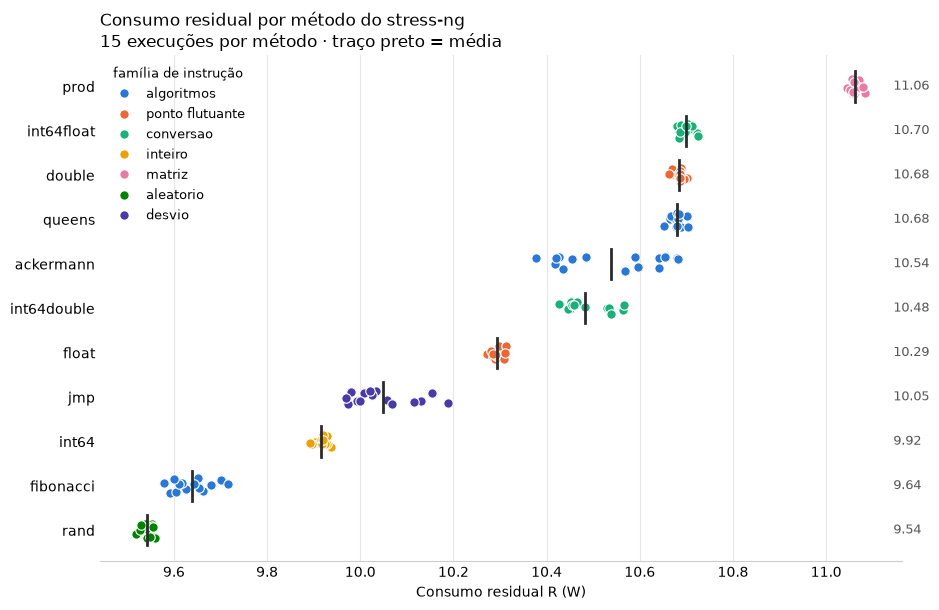

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CAMINHO = "../dados/log-consumo-residual.csv"

#paleta categorica validada (CVD dE 9.1 protan, normal 19.6)
CORES = {
    "algoritmos":      "#2a78d6",
    "ponto flutuante": "#eb6834",
    "conversao":       "#1baf7a",
    "inteiro":         "#eda100",
    "matriz":          "#e87ba4",
    "aleatorio":       "#008300",
    "desvio":          "#4a3aa7",
}
FAMILIA = {
    "ackermann": "algoritmos", "queens": "algoritmos", "fibonacci": "algoritmos",
    "float": "ponto flutuante", "double": "ponto flutuante",
    "int64float": "conversao", "int64double": "conversao",
    "int64": "inteiro", "prod": "matriz", "rand": "aleatorio", "jmp": "desvio",
}

#o log grava a mesma medicao duas vezes: a linha taskset (com desvio) e a linha
#residual (com null). fica so a taskset
df = pd.read_csv(CAMINHO, names=["nome", "potencia_w", "desvio_w"])
df = df[df["nome"].str.startswith("taskset")].copy()
df["metodo"] = df["nome"].str.extract(r"method-([a-z0-9]+)--t-")
df["familia"] = df["metodo"].map(FAMILIA)

ordem = df.groupby("metodo")["potencia_w"].mean().sort_values().index.tolist()
pos = {m: i for i, m in enumerate(ordem)}

fig, ax = plt.subplots(figsize=(9.5, 6.2))
rng = np.random.default_rng(0)

for metodo in ordem:
    sub = df[df["metodo"] == metodo]
    y = pos[metodo] + rng.uniform(-0.17, 0.17, len(sub))
    ax.scatter(sub["potencia_w"], y, s=46, color=CORES[FAMILIA[metodo]],
               edgecolor="white", linewidth=0.8, zorder=3)
    media = sub["potencia_w"].mean()
    ax.plot([media, media], [pos[metodo] - 0.34, pos[metodo] + 0.34],
            color="#2b2b2b", linewidth=2, zorder=4)
    ax.text(df["potencia_w"].max() + 0.06, pos[metodo], f"{media:.2f}",
            va="center", fontsize=9, color="#555555")

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels(ordem)
ax.set_xlabel("Consumo residual R (W)")
ax.set_title("Consumo residual por método do stress-ng\n"
             "15 execuções por método · traço preto = média",
             loc="left", fontsize=12)
ax.grid(axis="x", color="#e6e6e6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(length=0)
ax.set_ylim(-0.7, len(ordem) - 0.3)

vistos = []
for fam in CORES:
    if fam in df["familia"].values:
        vistos.append(plt.Line2D([], [], marker="o", linestyle="", markersize=7,
                                 markerfacecolor=CORES[fam], markeredgecolor="white",
                                 label=fam))
ax.legend(handles=vistos, loc="upper left", frameon=False, fontsize=9,
          title="família de instrução", title_fontsize=9)

fig.tight_layout()
fig.savefig("residual_por_metodo.png", dpi=150)